<a href="https://colab.research.google.com/github/orlamurphy5/Coursework/blob/main/Econ%20Quant%20%2B%20Stats%20Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/orlamurphy5/Coursework/main/loan50.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/orlamurphy5/Coursework/main/ncbirths.csv')
df3 = pd.read_csv('https://raw.githubusercontent.com/orlamurphy5/Coursework/main/mariokart.csv')

In [13]:
import pandas as pd

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50, 18)


,state,emp_length,term,homeownership,annual_income,verified_income,debt_to_income,total_credit_limit,total_credit_utilized,num_cc_carrying_balance,loan_purpose,loan_amount,grade,interest_rate,public_record_bankrupt,loan_status,has_second_income,total_income
0,NJ,3.0,60,rent,59000,Not Verified,0.557525,95131,32894,8,debt_consolidation,22000,B,10.90,0,Current,False,59000
1,CA,10.0,36,rent,60000,Not Verified,1.305683,51929,78341,2,credit_card,6000,B,9.92,1,Current,False,60000
2,SC,NaN,36,mortgage,75000,Verified,1.056280,301373,79221,14,debt_consolidation,25000,E,26.30,0,Current,False,75000
3,CA,0.0,36,rent,75000,Not Verified,0.574347,59890,43076,10,credit_card,6000,B,9.92,0,Current,False,75000
4,OH,4.0,60,mortgage,254000,Not Verified,0.238150,422619,60490,2,home_improvement,25000,B,9.43,0,Current,False,254000


In [14]:
import pandas as pd

df[['loan_amount', 'interest_rate', 'term', 'grade', 'state', 'homeownership']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   loan_amount    50 non-null     int64  
 1   interest_rate  50 non-null     float64
 2   term           50 non-null     int64  
 3   grade          50 non-null     object 
 4   state          50 non-null     object 
 5   homeownership  50 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 2.5+ KB


In [15]:
stats = df['interest_rate'].describe()

iqr = stats['75%'] - stats['25%']

print(stats)
print(f"Interquartile Range (IQR): {iqr}")

count    50.000000
mean     11.567200
std       5.052115
min       5.310000
25%       7.960000
50%       9.930000
75%      13.715000
max      26.300000
Name: interest_rate, dtype: float64
Interquartile Range (IQR): 5.755


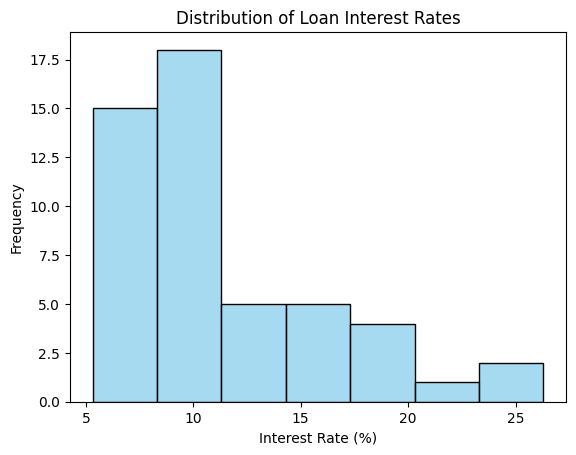

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['interest_rate'], kde=False, color='skyblue')

plt.title('Distribution of Loan Interest Rates')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Frequency')

plt.show()

Frequency Table for Homeownership:
homeownership
mortgage    26
rent        21
own          3
Name: count, dtype: int64


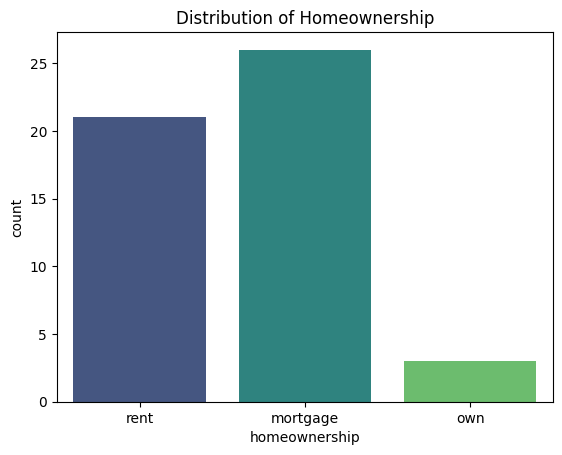

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

home_counts = df['homeownership'].value_counts()
print("Frequency Table for Homeownership:")
print(home_counts)

sns.countplot(data=df, x='homeownership', hue='homeownership', palette='viridis', legend=False)
plt.title('Distribution of Homeownership')
plt.show()

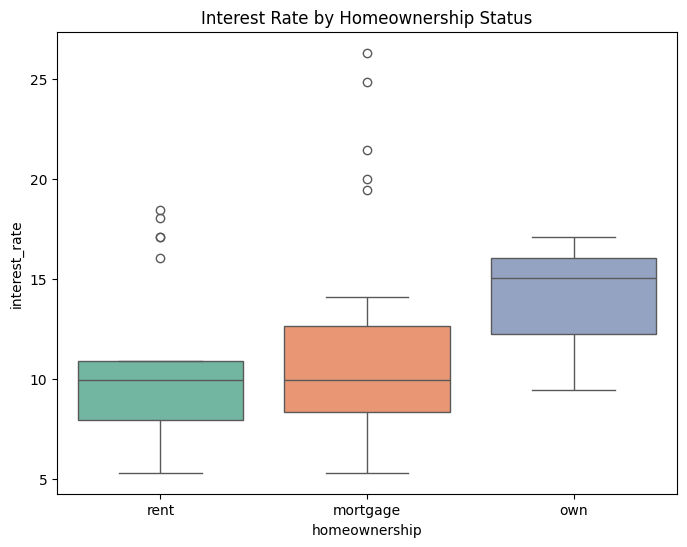

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='homeownership', y='interest_rate', hue='homeownership',palette='Set2', legend=False)
plt.title('Interest Rate by Homeownership Status')
plt.show()

In [22]:
import pandas as pd
import numpy as np
from scipy import stats

df2['premature'] = (df2['weeks'] < 37).astype(float)

table = pd.crosstab(df2['habit'], df2['premature'])
table.columns = ['Full Term', 'Premature']
table.index = ['Nonsmoker', 'Smoker']

table['Total'] = table.sum(axis=1)
table['% Premature'] = (table['Premature'] / table['Total'] * 100).round(2)

print(table)

n_ns = table.loc['Nonsmoker', 'Total']
x_ns = table.loc['Nonsmoker', 'Premature']
n_s = table.loc['Smoker', 'Total']
x_s = table.loc['Smoker', 'Premature']

p_ns = x_ns / n_ns
p_s = x_s / n_s

p_pool = (x_s + x_ns) / (n_s + n_ns)

se = np.sqrt(p_pool * (1 - p_pool) * (1/n_s + 1/n_ns))

z = (p_s - p_ns) / se

p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"\n--- Stat Result ---")
print(f"P-value: {p_value:.4f}")

           Full Term  Premature  Total  % Premature
Nonsmoker        740        133    873        15.23
Smoker           107         19    126        15.08

--- Stat Result ---
P-value: 0.9638


In [24]:
import pandas as pd
import numpy as np
from scipy import stats

df2['premature'] = (df2['weeks'] < 37).astype(int)

table = pd.crosstab(df2['habit'], df2['premature'])

n_ns = table.loc['nonsmoker'].sum()
x_ns = table.loc['nonsmoker', 1]
p_ns = x_ns / n_ns

n_s = table.loc['smoker'].sum()
x_s = table.loc['smoker', 1]
p_s = x_s / n_s

diff = p_s - p_ns

z_star = stats.norm.ppf(0.975)
se = np.sqrt((p_s * (1 - p_s) / n_s) + (p_ns * (1 - p_ns) / n_ns))

lower = diff - z_star * se
upper = diff + z_star * se

print(f"95% Confidence Interval: ({lower:.4f}, {upper:.4f})")

95% Confidence Interval: (-0.0684, 0.0653)


In [25]:
import pandas as pd
import numpy as np
from scipy import stats

n_ns = 873; x_ns = 133
n_s = 126; x_s = 19

p_ns = x_ns / n_ns
p_s = x_s / n_s

p_pooled = (x_s + x_ns) / (n_s + n_ns)
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_s + 1/n_ns))

z_stat = (p_s - p_ns) / se_pooled

p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"Test Statistic (Z): {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")


Test Statistic (Z): -0.0454
P-value: 0.9638


In [28]:
import pandas as pd
import numpy as np
from scipy import stats

summary_stats = df2.groupby('habit')['weight'].agg(['mean', 'std', 'count']).round(3)

print("Summary Statistics by Habit:")
print(summary_stats)

nonsmoker_w = df2[df2['habit'] == 'nonsmoker']['weight'].dropna()
smoker_w = df2[df2['habit'] == 'smoker']['weight'].dropna()

t_stat, p_val = stats.ttest_ind(nonsmoker_w, smoker_w, equal_var=False)

def welch_df(v1, n1, v2, n2):
    num = (v1/n1 + v2/n2)**2
    den = (v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1)
    return num / den

df_val = welch_df(nonsmoker_w.var(), len(nonsmoker_w), smoker_w.var(), len(smoker_w))

print("\n--- Question 8(c): T-Test Results ---")
print(f"Test Statistic (t): {t_stat:.4f}")
print(f"Degrees of Freedom: {df_val:.2f}")
print(f"P-value: {p_val:.4f}")

Summary Statistics by Habit:
            mean    std  count
habit                         
nonsmoker  7.144  1.519    873
smoker     6.829  1.386    126

--- Question 8(c): T-Test Results ---
Test Statistic (t): 2.3590
Degrees of Freedom: 171.32
P-value: 0.0195


In [29]:
from scipy import stats

t_stat, p_val = stats.ttest_ind(nonsmoker_w, smoker_w, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

T-statistic: 2.3590109449335013
P-value: 0.01945055644373227


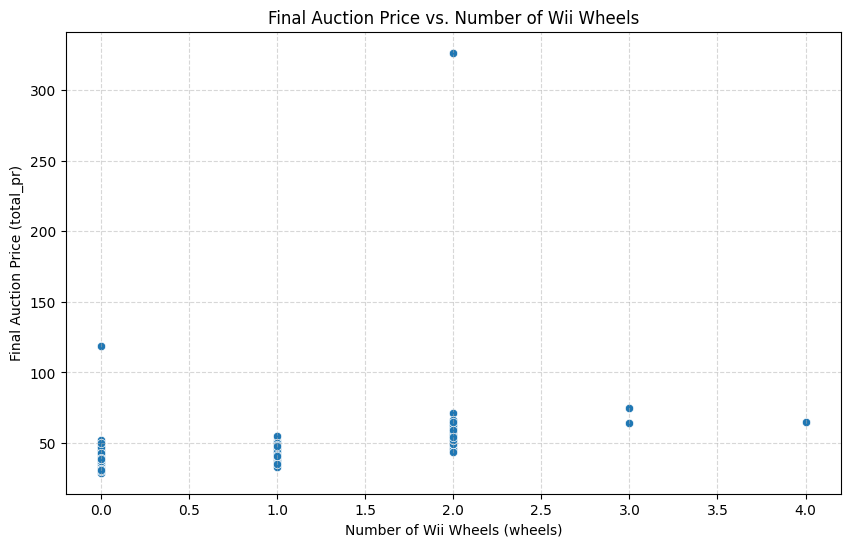

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(x='wheels', y='total_pr', data=df3)

plt.title('Final Auction Price vs. Number of Wii Wheels')
plt.xlabel('Number of Wii Wheels (wheels)')
plt.ylabel('Final Auction Price (total_pr)')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [35]:
import pandas as pd
import statsmodels.formula.api as smf

X = df3['wheels']
y = df3['total_pr']

model = smf.ols('total_pr ~ wheels', data=df3).fit()

print("Coefficients:")
print(model.params)

Coefficients:
Intercept    38.405219
wheels       10.005876
dtype: float64


                            OLS Regression Results                            
Dep. Variable:               total_pr   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     17.23
Date:                Fri, 15 May 2026   Prob (F-statistic):           5.70e-05
Time:                        19:21:53   Log-Likelihood:                -658.35
No. Observations:                 143   AIC:                             1321.
Df Residuals:                     141   BIC:                             1327.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.4052      3.433     11.188      0.0

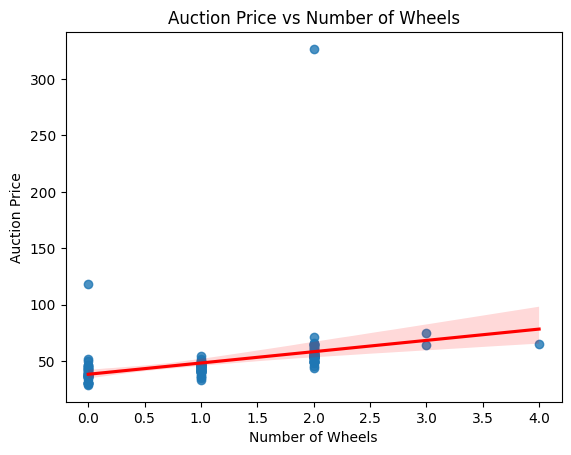

<Axes: title={'center': 'Residual Plot'}, xlabel='wheels', ylabel='total_pr'>

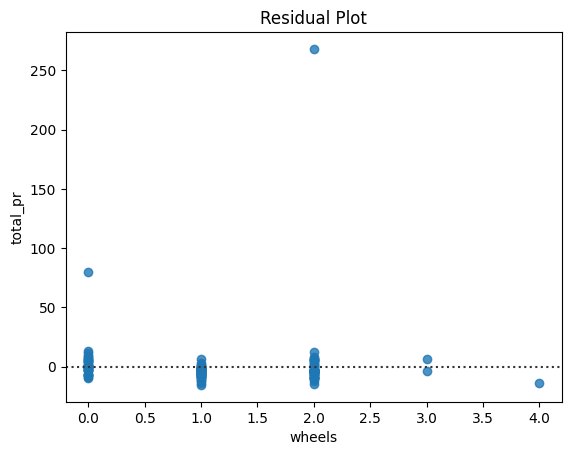

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

model = smf.ols('total_pr ~ wheels', data=df3).fit()
print(model.summary())

sns.regplot(x='wheels', y='total_pr', data=df3, line_kws={"color": "red"})
plt.title('Auction Price vs Number of Wheels')
plt.xlabel('Number of Wheels')
plt.ylabel('Auction Price')
plt.show()

plt.title('Residual Plot')
sns.residplot(x='wheels', y='total_pr', data=df3)

                            OLS Regression Results                            
Dep. Variable:               total_pr   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     8.573
Date:                Fri, 15 May 2026   Prob (F-statistic):           0.000307
Time:                        19:22:13   Log-Likelihood:                -658.33
No. Observations:                 143   AIC:                             1323.
Df Residuals:                     140   BIC:                             1332.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       37.6673      5.279      7.135   

Text(40.9277265625, 0.5, 'Auction Price')

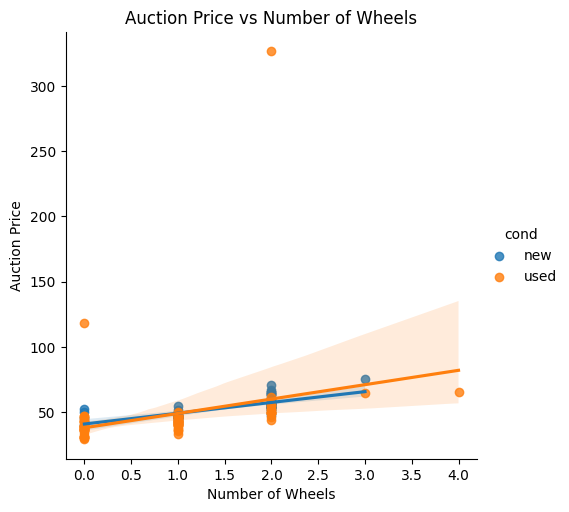

In [39]:
multi_model = smf.ols('total_pr ~ wheels + cond', data=df3).fit()
print(multi_model.summary())

sns.lmplot(x='wheels', y='total_pr', hue='cond', data=df3)
plt.title('Auction Price vs Number of Wheels')
plt.xlabel('Number of Wheels')
plt.ylabel('Auction Price')


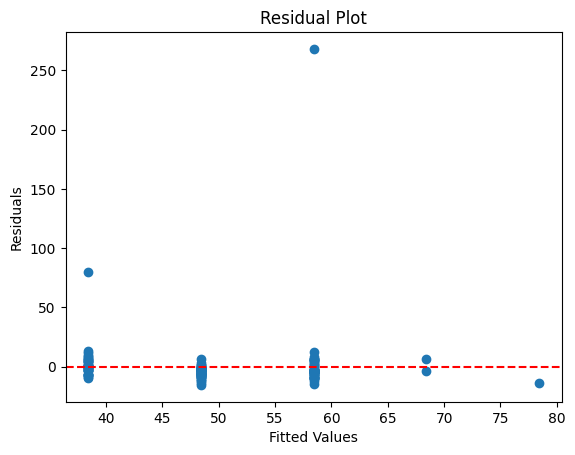

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fitted_values = model.fittedvalues
residuals = model.resid

plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()